Imports

In [8]:
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from sentence_transformers import SentenceTransformer


Extract Questions

In [9]:
cq_path = "competency_questions_all_documents.txt"

with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

# Extract all questions from the file
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.|\Z)', content, re.DOTALL)


Clustering and Plotting Function

In [10]:
def cluster_and_plot_cq(distances, model, method='ward'):
    """
    Plot a dendrogram based on the given distance matrix.
    """
    # Perform hierarchical clustering
    Z = linkage(distances, method=method)

    # Create a dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(Z, labels=questions, leaf_rotation=90)
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorization")
    plt.xlabel("Questions")
    plt.ylabel("Distance")
    plt.show()


TF-IDF-Vektorisierung

C:\Users\fabia\AppData\Local\Temp\ipykernel_8596\1562976203.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distances, method=method)


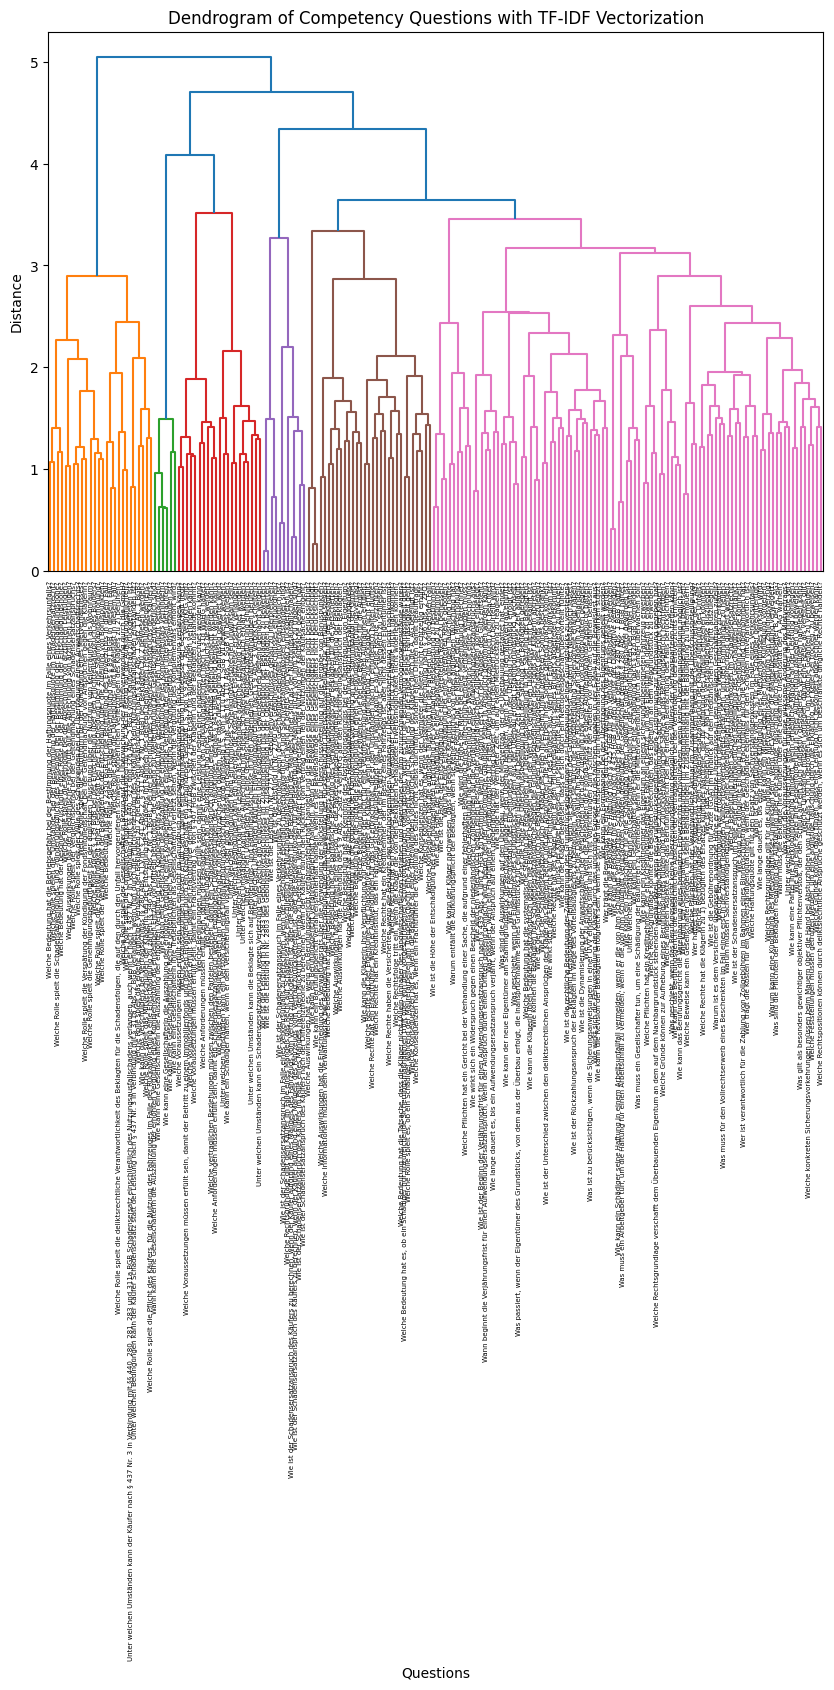

In [11]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

distances = pdist(X.toarray(), metric="cosine")

cluster_and_plot_cq(squareform(distances), "TF-IDF", method='ward')

Sentence Embedding Vertorisierung

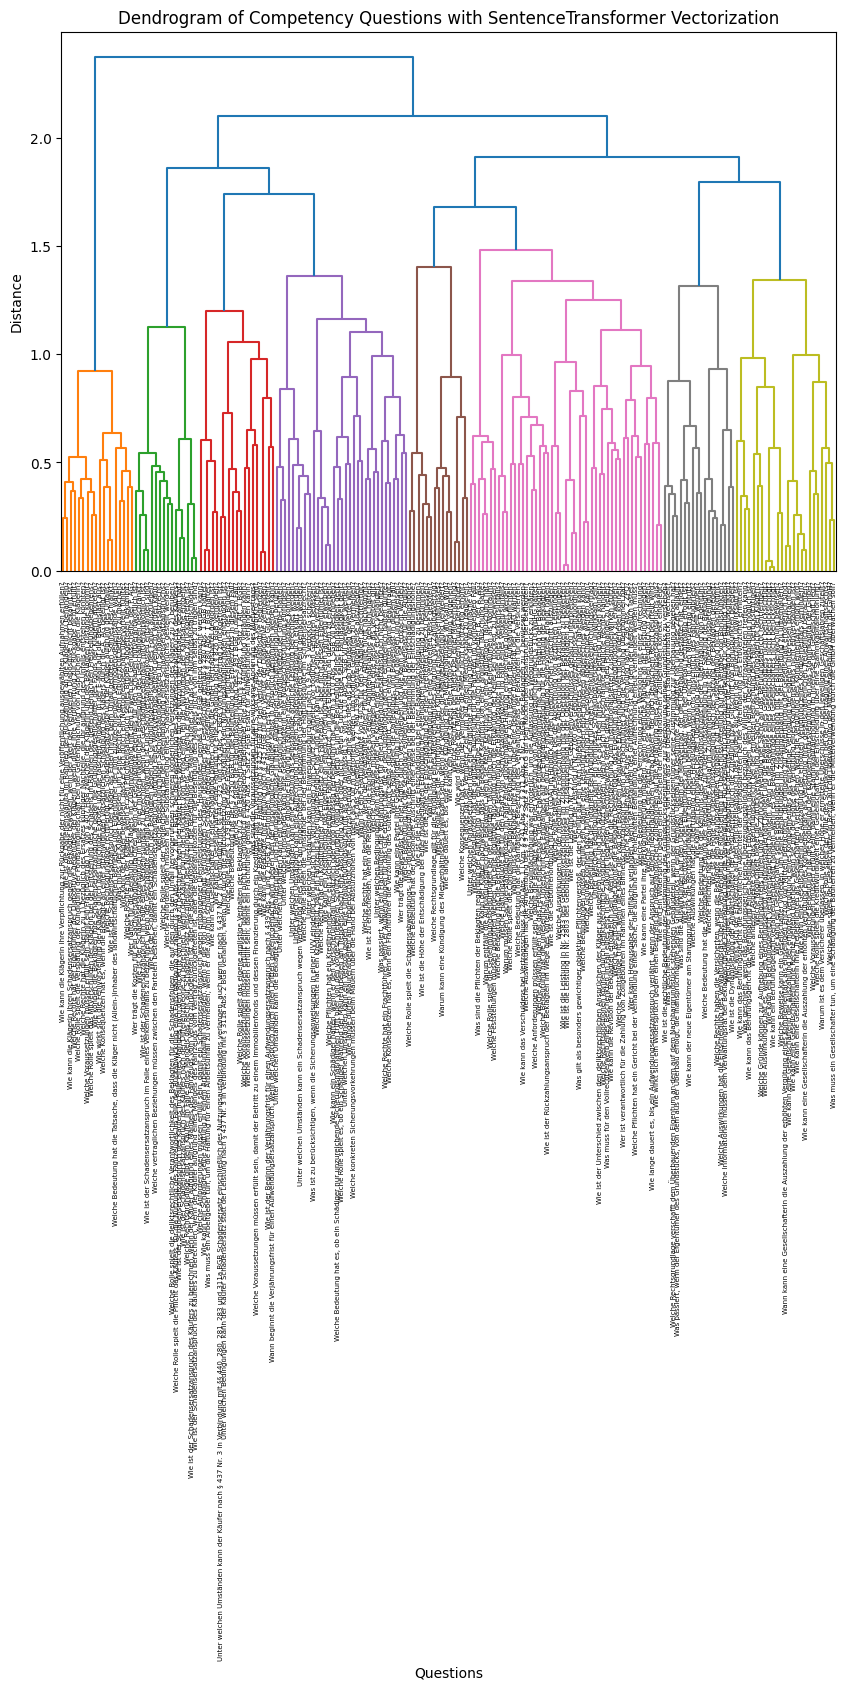

In [12]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # You can choose other models from sentence-transformers

# Generate embeddings for all questions
embeddings = model.encode(questions)

# Calculate pairwise cosine distances
distances = pdist(embeddings, metric="cosine")

cluster_and_plot_cq(distances, "SentenceTransformer", method='ward')
